In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

Maximal Cliques: [[3, 1, 2], [3, 4, 5], [6, 5, 7]]


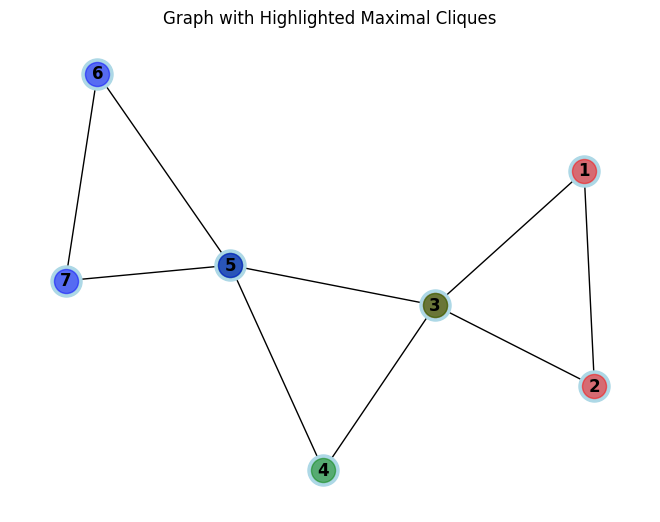

In [ ]:
G_clique = nx.Graph()
G_clique.add_edges_from([
    (1, 2), (2, 3), (3, 1),
    (3, 4), (4, 5), (5, 3),
    (5, 6), (6, 7), (7, 5)
])

cliques = list(nx.find_cliques(G_clique))
print(f"Maximal Cliques: {cliques}")

plt.clf()
pos = nx.spring_layout(G_clique)
nx.draw(G_clique, pos, with_labels=True, node_color='lightblue', node_size=500, font_weight='bold')

colors = ['red', 'green', 'blue']
for i, clique in enumerate(cliques):
    nx.draw_networkx_nodes(G_clique, pos, nodelist=clique, node_color=colors[i % len(colors)], alpha=0.5)

plt.title("Graph with Highlighted Maximal Cliques")
plt.show()

Simple Graphs Isomorphic: False


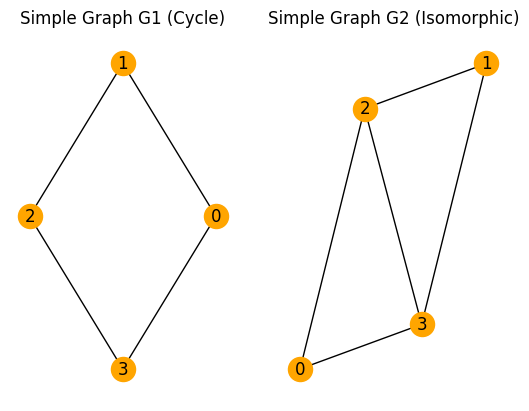

In [ ]:
G1 = nx.cycle_graph(4)
G2 = nx.Graph([(0, 2), (2, 1), (1, 3), (3, 0), (2,3)])

is_iso_simple = nx.is_isomorphic(G1, G2)
print(f"Simple Graphs Isomorphic: {is_iso_simple}")

plt.clf()
plt.subplot(1, 2, 1)
nx.draw_circular(G1, with_labels=True, node_color='orange')
plt.title("Simple Graph G1 (Cycle)")

plt.subplot(1, 2, 2)
nx.draw_spring(G2, with_labels=True, node_color='orange')
plt.title("Simple Graph G2 (Isomorphic)")
plt.show()

Multigraphs Isomorphic: True


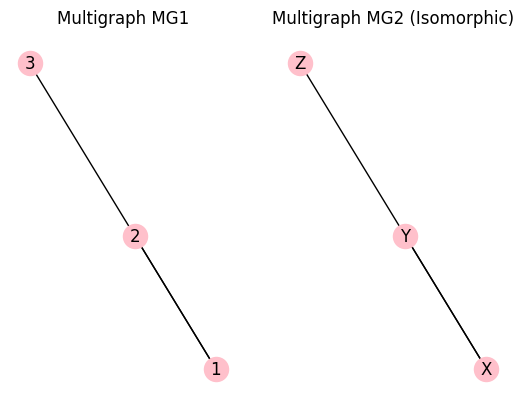

In [ ]:
MG1 = nx.MultiGraph()
MG1.add_edges_from([(1, 2), (1, 2), (2, 3)])

MG2 = nx.MultiGraph()
MG2.add_edges_from([('X', 'Y'), ('X', 'Y'), ('Y', 'Z')])

is_iso_multi = nx.is_isomorphic(MG1, MG2)
print(f"Multigraphs Isomorphic: {is_iso_multi}")

plt.clf()
plt.subplot(1, 2, 1)
nx.draw(MG1, with_labels=True, node_color='pink')
plt.title("Multigraph MG1")

plt.subplot(1, 2, 2)
nx.draw(MG2, with_labels=True, node_color='pink')
plt.title("Multigraph MG2 (Isomorphic)")
plt.savefig("multigraph_isomorphism.png")

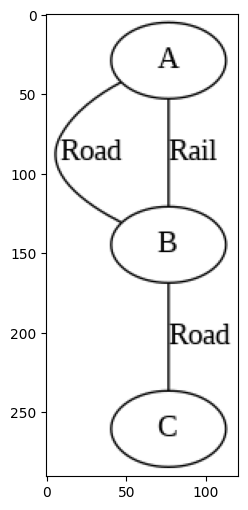

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

MG = nx.MultiGraph()
MG.add_edge('A', 'B', key='edge1', weight=1, label='Road')
MG.add_edge('A', 'B', key='edge2', weight=5, label='Rail')
MG.add_edge('B', 'C', key='edge3', weight=2, label='Road')
P = nx.drawing.nx_pydot.to_pydot(MG)
P.write_png('multigraph_graphviz.png')

plt.figure(figsize=(8, 6))
img = mpimg.imread('multigraph_graphviz.png')
plt.imshow(img)

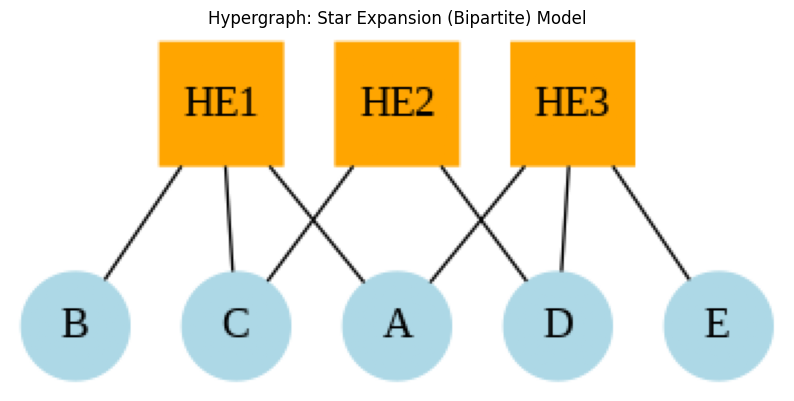

In [ ]:
import graphviz

hypergraph = {
    'HE1': ['A', 'B', 'C'],
    'HE2': ['C', 'D'],
    'HE3': ['A', 'D', 'E']
}

dot = graphviz.Graph('Hypergraph', comment='Star Expansion Representation')

dot.attr('node', shape='circle', style='filled', color='lightblue')

members = set(m for members in hypergraph.values() for m in members)
for m in members:
    dot.node(m, label=m)

dot.attr('node', shape='square', color='orange', style='filled')
for he, m_list in hypergraph.items():
    dot.node(he, label=he)
    for m in m_list:
        dot.edge(he, m)

dot.render('hypergraph_output', format='png', cleanup=True)

plt.figure(figsize=(10, 8))
img = mpimg.imread('hypergraph_output.png')
plt.imshow(img)
plt.axis('off')
plt.title("Hypergraph: Star Expansion (Bipartite) Model")
plt.show()